In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

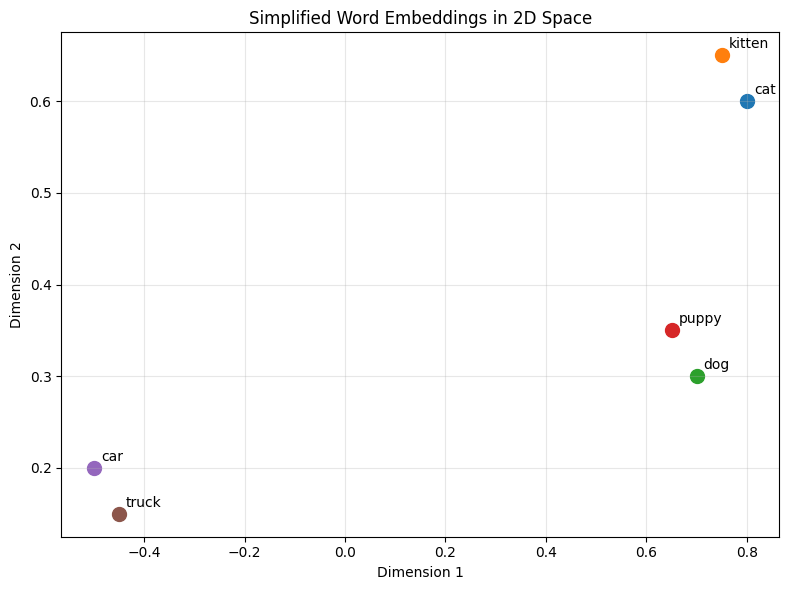

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5), 
                textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Measuring Similarity

In [4]:
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposite meanings
    """

    dot_product=np.dot(vec1,vec2)
    norm_a=np.linalg.norm(vec1)
    norm_b=np.linalg.norm(vec2)
    return dot_product/(norm_a * norm_b)



In [5]:
# Example
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity=cosine_similarity(cat_vector,kitten_vector)
print(cat_kitten_similarity)

0.9966186334192183


In [6]:
cosine_similarity(cat_vector,car_vector)

np.float64(-0.4371858854891681)

In [7]:
from langchain_huggingface import HuggingFaceEmbeddings

# Initializing an Embedding model
embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
embeddings 

c:\Users\91767\Desktop\Practice\RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [8]:
## creating embeddings
text="Hello, Create this into vector embeddings."

embedding=embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embedding length : {len(embedding)}")
print(embedding)


Text: Hello, Create this into vector embeddings.
Embedding length : 384
[-0.027148336172103882, -0.01777038536965847, -0.06802746653556824, -0.023014873266220093, -0.03621125966310501, 0.009331299923360348, -0.008371320553123951, -0.006876570172607899, -0.019460542127490044, -0.054867539554834366, -0.0323939248919487, 0.039827585220336914, 0.020528938621282578, 0.08658328652381897, -0.08129923045635223, 0.0124093908816576, -0.01989716663956642, 0.05807172879576683, 0.004357222467660904, 0.01865965873003006, 0.007684195879846811, -0.04109903424978256, 0.08190402388572693, -0.0693785697221756, 0.035669729113578796, -0.01121561974287033, 0.03888511285185814, 0.04358846694231033, 0.05278090760111809, -0.02350422367453575, 0.08676981180906296, -0.006826105527579784, 0.009740815497934818, 0.08795908093452454, -0.08350705355405807, 0.011033087968826294, -0.04961753636598587, 0.0977533683180809, -0.04292971268296242, -0.0011000907979905605, 0.02042313478887081, 0.07669133692979813, 0.056045070

In [9]:
sentences = [
    "The cat sat on the mat",
    "The cat sat on the mat",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]

embedding_sentence=embeddings.embed_documents(sentences)

print(embedding_sentence[0])
print(embedding_sentence[1])

[0.1304018497467041, -0.011870148591697216, -0.02811707742512226, 0.05123859643936157, -0.05597455054521561, 0.030191544443368912, 0.030161334201693535, 0.024698354303836823, -0.018370533362030983, 0.05876684561371803, -0.024953192099928856, 0.06015422195196152, 0.039831701666116714, 0.03323056921362877, -0.06131143122911453, -0.049373093992471695, -0.05486350879073143, -0.040076106786727905, 0.05642911046743393, 0.03915660083293915, -0.034737054258584976, -0.013247678987681866, 0.03196614608168602, -0.06349923461675644, -0.06017854064702988, 0.07823454588651657, -0.028303848579525948, -0.04744282737374306, 0.04035931080579758, -0.0066308933310210705, -0.06674092262983322, -0.004191305488348007, -0.025311704725027084, 0.05334162339568138, 0.017428148537874222, -0.09792355448007584, 0.006061299704015255, -0.06524168699979782, 0.04557259380817413, 0.023641807958483696, 0.07658479362726212, -0.010264316573739052, -0.004076763521879911, -0.06232282891869545, 0.03370523452758789, 0.01866111